In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_and_process_results,
    match_datasets,
    matching_precision_recall,
    get_filenames_in_directory,
    fit_temperature,
    apply_temperature,
    fit_temperature_from_probs,
    apply_temperature_from_probs,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

### Ground Truth Dataset

In [2]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/pond/directory.json"), "r") as f:
    paper_info = json.load(f)

paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

'''
paper_subset = [
    'agricultural_freshwater',
    'analysis_of_biological',
    'application_and_transferability',
    'aquatic_insect_assemblages',
    'bacterial_processes'
]
'''

'''
paper_subset = [
    'physical-chemical_influences',
    'environmental_conditions',
    'relative_contribution',
    'monitoring_status',
    'characterizing_ponds',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes',
    'macroinvertebrate_size',
    'biodiversity_of_constructed',
    'conservation_of_pond',
]
'''


#paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()

ground_truth_df = pd.read_csv("../data/pond/pond_data_corrected.csv", encoding_errors='ignore', index_col = 0)
ground_truth_df = ground_truth_df.loc[ground_truth_df.title.isin(registered_titles)]
ground_truth_df = ground_truth_df.reset_index(drop=True)

In [5]:
ground_truth_df.title.value_counts()[:10]

title
classification trees as a tool for predicting cyanobacterial blooms                                                                                                      192
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa                                                     162
habitat characteristics and odonate diversity in mountain ponds of central italy                                                                                         155
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                               152
prairie wetland communities recover at different rates following hydrological restoration                                                                                144
macroinvertebrate size spectra of mediterranean ponds with differing hydroperiod length                                          

### Data from Intermediate Pipeline steps

In [4]:
main_directory = "../data/pond"
pdf_directory = os.path.join(main_directory, "pdfs")
ocr_directory = os.path.join(main_directory, "ocr_output_cleaned_gpt_5_mini")
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)

text_files = get_filenames_in_directory(ocr_directory, ignore = [".DS_Store", ".gitkeep"])
text_files.sort()

titles = [paper_info[file.replace('.txt', '')]['title'] for file in text_files]

**1. Extracted Entities**

In [6]:
extracted_entity_data_path = "../data/experiments/2026_03_04/pond_entities.json"

with open(extracted_entity_data_path, "r") as f:
    extracted_entity_data = json.load(f)

extracted_entity_data = [e | {'title': titles[e['document_id']]} for e in extracted_entity_data]

entity_strict_fields = ["title"]
entity_fuzzy_fields = ["name", "location", "ecosystem"]

extracted_entity_df = pd.DataFrame(extracted_entity_data)
extracted_entity_df = extracted_entity_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
extracted_entity_df = extracted_entity_df.reset_index(drop=True)

ground_truth_entity_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
ground_truth_entity_df = ground_truth_entity_df.reset_index(drop=True)

In [7]:
entity_matching, entity_recall, entity_precision = matching_precision_recall(
    ground_truth_entity_df,
    extracted_entity_df,
    strict_matching = {'title': 'title'},
    fuzzy_matching = {'name':'name', 'location':'location', 'ecosystem': 'ecosystem'},
    fuzzy_threshold = 0.5
)

In [8]:
entity_recall

0.7953410981697171

In [9]:
entity_precision

0.4681684622918707

**2. Detected Attributes**

In [10]:
extracted_attribute_data_path = "../data/experiments/2026_03_04/pond_attributes.json"

with open(extracted_attribute_data_path, "r") as f:
    extracted_attribute_data = json.load(f)

extracted_attribute_dataset = []
for doc_id, attr_dict in extracted_attribute_data.items():
    for attr in attr_dict.keys():
        extracted_attribute_dataset.append({'title': titles[int(doc_id)], 'attribute': attr})

entity_strict_fields = ["title", "attribute"]

extracted_attribute_df = pd.DataFrame(extracted_attribute_dataset)
extracted_attribute_df = extracted_attribute_df.drop_duplicates(subset = entity_strict_fields)

ground_truth_attribute_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields)

In [11]:
attribute_matching, attribute_recall, attribute_precision = matching_precision_recall(
    ground_truth_attribute_df,
    extracted_attribute_df,
    strict_matching = {'title':'title', 'attribute':'attribute'},
    fuzzy_matching = {},
    fuzzy_threshold = 0.0
)

In [12]:
attribute_recall

0.9536231884057971

In [13]:
attribute_precision

0.6388349514563106

### Full, Extracted Dataset

In [12]:
# ---------------------------------
# Load experiment results
# ---------------------------------

#experiment_data_path = "../data/experiments/2026_03_04/pond_judged_combined.json"
experiment_data_path = "../data/experiments/pond/extraction/qwen-3.5-27b/2026_04_12/final.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1.0, "fraction": 100.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)
extracted_df.reset_index(drop=True, inplace=True)

In [15]:
extracted_df.loc[:,'date']

0          None
1       10-2014
2       11-2014
3       12-2014
4          None
         ...   
4253        NaN
4254        NaN
4255        NaN
4256        NaN
4257        NaN
Name: date, Length: 4258, dtype: str

### Match Extractions to Ground Truth

In [14]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "title": "title", # name in the ground truth dataset : name in the extracted dataset
    "attribute": "attribute",
    "value": "processed_value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "name": "name",
    "location": "location",
    "ecosystem": "ecosystem",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, matching_recall, matching_precision = matching_precision_recall(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching,
    fuzzy_threshold = 1/3
)

print(f"Recall: {matching_recall:.4f}")
print(f"Precision: {matching_precision:.4f}")

Recall: 0.6481
Precision: 0.5190


### Debugging:

In [12]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [78]:
unmatched_gt_df.title.value_counts().head(10)

title
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa                                                               96
environmental conditions and macrophytes of karst ponds                                                                                                                            84
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            78
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             56
biodiversity of constructed wetlands for wastewater treatment                       

In [68]:
unmatched_gt_df.title.value_counts().head(10)

title
environmental conditions and macrophytes of karst ponds                                                                                                                            81
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            77
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                                         74
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             63
relationships between fish feeding guild and trophic structure in english lowland sh

In [20]:
matched_gt_df.title.value_counts()

title
vegetation-environmental variable relationships in ponds of various origins along an altitudinal gradient                        43
distinct optical chemistry of dissolved organic matter in urban pond ecosystems                                                  29
productivity and depth regulate lake contributions to atmospheric methane                                                        19
lake morphometry moderates the relationship between water color and fish biomass in small boreal lakes                           16
sediment characteristics and accumulation rates in constructed ponds                                                             10
natural variability of carbon dioxide and net epilimnetic production in the surface waters of boreal lakes of different sizes     4
fish assemblages in floodplain lakes in a neotropical river during the wet season (magdalena river; colombia)                     3
conservation of pond systems: a case study of intractability; brown mo

In [85]:
title = "biodiversity of constructed wetlands for wastewater treatment"
gt_title_df = ground_truth_df.loc[ground_truth_df.title == title]
unmatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = extracted_df.loc[extracted_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

### Judgement

In [11]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] | matching_status
extracted_df['matching_status'] = matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [12]:
# Initial Precision
(extracted_df['validation'] == True).sum() / len(extracted_df)

np.float64(0.5829620629134602)

In [12]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

prediction_dict = {
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
    "llama": extracted_df['judgement_llama'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  FPR:       {fpr:.4f}")
    print()

Model: gpt
  TP=4123, FP=172, TN=2917, FN=195
  Accuracy:  0.9505
  Precision: 0.9600
  Recall:    0.9548
  F1:        0.9574
  FPR:       0.0557

Model: gemini
  TP=4215, FP=748, TN=2341, FN=103
  Accuracy:  0.8851
  Precision: 0.8493
  Recall:    0.9761
  F1:        0.9083
  FPR:       0.2421

Model: claude
  TP=2916, FP=4, TN=3085, FN=1402
  Accuracy:  0.8102
  Precision: 0.9986
  Recall:    0.6753
  F1:        0.8057
  FPR:       0.0013

Model: llama
  TP=978, FP=214, TN=2875, FN=3340
  Accuracy:  0.5202
  Precision: 0.8205
  Recall:    0.2265
  F1:        0.3550
  FPR:       0.0693



### Baseline Calibration

In [13]:
# ── Publication style ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 300,
})

COLORS = {
    "llama": "#1b6ca8",
    "gpt":   "#c44e52",
    "diag":  "#333333",
}

In [14]:
# ── Compute calibration values ──
def compute_calibration(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = bin_labels.mean()
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }

In [15]:
# ── Llama baseline next token probability calibration ──
llama_p_true = extracted_df['judgement_p_true_llama'].to_numpy()
cal_llama_baseline = compute_calibration(llama_p_true, labels)

logits_true = extracted_df['judgement_logit_p_true_llama'].to_numpy()
logits_false = extracted_df['judgement_logit_p_false_llama'].to_numpy()
best_t = fit_temperature(logits_true, logits_false, labels)
llama_p_true_temp, llama_p_false_temp = apply_temperature(logits_true, logits_false, best_t)
cal_llama_baseline_temp = compute_calibration(llama_p_true_temp, labels)

### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns. 

In [16]:
def grouped_kfold_split(titles, n_splits=5, random_state=42):
    """
    Group-based k-fold CV split by paper title (no title leakage).
    
    Shuffles unique titles, then greedily assigns them to folds
    until each fold reaches ~1/k of total samples. Guarantees that
    no paper appears in more than one fold.
    
    Parameters
    ----------
    titles : array-like of str
        Paper title for each sample.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed for reproducibility.
    
    Yields
    ------
    train_idx, test_idx : np.ndarray, np.ndarray
        Integer indices for each fold.
    """
    rng = np.random.RandomState(random_state)
    titles = np.asarray(titles)
    unique_titles = np.array(list(set(titles)))
    rng.shuffle(unique_titles)
    
    n_total = len(titles)
    
    # --- Greedily assign titles to folds ---
    fold_titles = [set() for _ in range(n_splits)]
    fold_counts = [0] * n_splits
    
    # Pre-compute counts per title
    title_counts = {t: int((titles == t).sum()) for t in unique_titles}
    
    target_per_fold = n_total / n_splits
    
    for t in unique_titles:
        n_t = title_counts[t]
        # Assign to the fold that is currently most under-filled
        best_fold = min(range(n_splits), key=lambda f: fold_counts[f])
        fold_titles[best_fold].add(t)
        fold_counts[best_fold] += n_t
    
    # --- Yield train/test splits ---
    for i in range(n_splits):
        test_mask = np.isin(titles, list(fold_titles[i]))
        train_mask = ~test_mask
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        yield train_idx, test_idx

In [17]:
attn_outputs = np.load("../data/experiments/2026_03_04/pond_judged_llama_attention_outputs.npz")

# Run a logistic regression predictor for each head/layer combination, 
# and return 5-fold cross validated test accuracy.
# Uses the group-based (by-title) k-fold train/test split defined above.
def run_logistic(X, y):
    accuracies = []
    for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values, random_state = 42)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        accuracies.append(float(model.score(X_test, y_test)))
    return np.mean(accuracies)

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

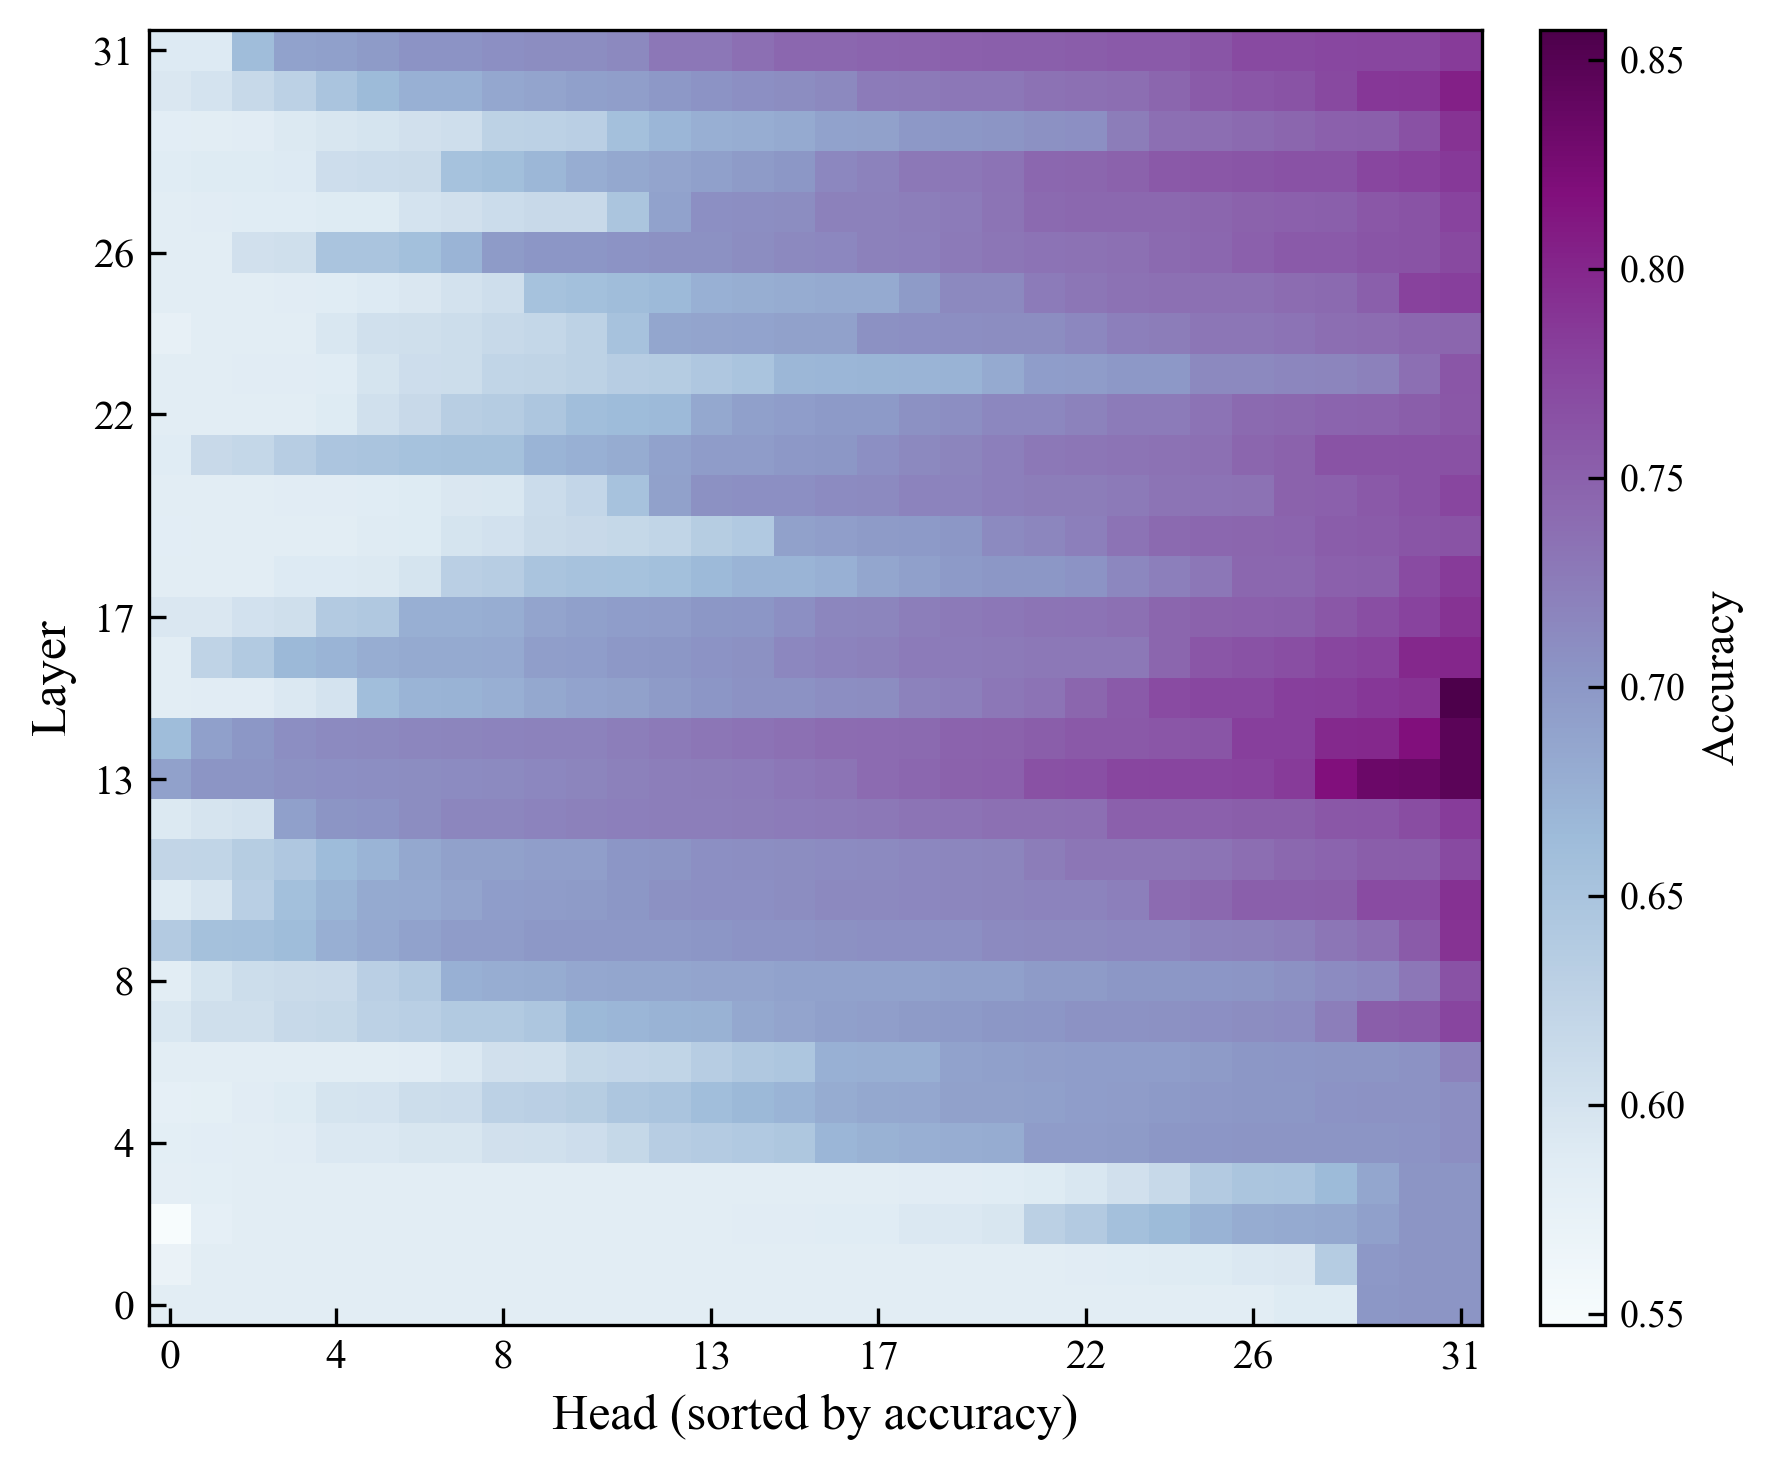

In [18]:
# ── Publication style (if not already set) ──
'''
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})
'''

predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)

fig, ax = plt.subplots(figsize=(6, 5))

pos = ax.imshow(predictor_accuracy_sorted, cmap="BuPu", aspect="auto", origin="lower")

ax.set_ylabel("Layer")
ax.set_xlabel("Head (sorted by accuracy)")
#ax.set_title("Attention Head Accuracies")

# Move x-axis labels/ticks to bottom (matshow puts them on top)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")

# Reduce tick clutter
n_layers, n_heads = predictor_accuracy_sorted.shape
ax.set_xticks(np.linspace(0, n_heads - 1, min(n_heads, 8)).astype(int))
ax.set_yticks(np.linspace(0, n_layers - 1, min(n_layers, 8)).astype(int))

# Colorbar
cbar = fig.colorbar(pos, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()
#fig.savefig("../figures/probe.pdf", bbox_inches="tight", dpi=300)

In [19]:
from sklearn.metrics import roc_curve, auc

# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

accuracies = []
fprs = []
precisions = []
recalls = []
f1s = []
probs = []
test_labels = []
mean_fpr_grid = np.linspace(0, 1, 200)
fold_tprs = []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_bool = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_test).astype(bool)

    tp = int(((y_pred_bool == True) & (y_true == True)).sum())
    tn = int(((y_pred_bool == False) & (y_true == False)).sum())
    fp = int(((y_pred_bool == True) & (y_true == False)).sum())
    fn = int(((y_pred_bool == False) & (y_true == True)).sum())

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else float('nan')
    fold_denom = fp + tn
    fpr = (fp / fold_denom) if fold_denom > 0 else float('nan')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    fprs.append(fpr)

    # Per-fold reporting
    n_pos = int(y_true.sum())
    n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}")

    # Calibration
    y_prob = model.predict_proba(X_test)[:, 1]
    probs.append(y_prob)
    test_labels.append(y_test)

    # AUROC
    fpr_fold, tpr_fold, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_fold, tpr_fold)
    fold_aucs.append(roc_auc)

    # Interpolate TPR onto common FPR grid
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    fold_tprs.append(interp_tpr)

probs = np.concatenate(probs)
test_labels = np.concatenate(test_labels)

fold_tprs = np.array(fold_tprs)
mean_tpr = fold_tprs.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = fold_tprs.std(axis=0)
mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print()
print(f"Attn head model avg. accuracy:   {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Attn head model avg. precision:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Attn head model avg. recall:     {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Attn head model avg. F1:         {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Attn head model avg. FPR:        {np.mean(fprs):.4f} ± {np.std(fprs):.4f}")

  Fold 0: n=1442 (pos=751, neg=691) | Acc=0.8807  Prec=0.8386  Rec=0.9547  F1=0.8929  FPR=0.1997
  Fold 1: n=1542 (pos=828, neg=714) | Acc=0.8508  Prec=0.8367  Rec=0.8973  F1=0.8660  FPR=0.2031
  Fold 2: n=1538 (pos=920, neg=618) | Acc=0.8836  Prec=0.8880  Rec=0.9217  F1=0.9045  FPR=0.1731
  Fold 3: n=1446 (pos=1055, neg=391) | Acc=0.9039  Prec=0.9202  Rec=0.9507  F1=0.9352  FPR=0.2225
  Fold 4: n=1439 (pos=764, neg=675) | Acc=0.8548  Prec=0.8053  Rec=0.9581  F1=0.8751  FPR=0.2622

Attn head model avg. accuracy:   0.8748 ± 0.0197
Attn head model avg. precision:  0.8577 ± 0.0409
Attn head model avg. recall:     0.9365 ± 0.0235
Attn head model avg. F1:         0.8947 ± 0.0243
Attn head model avg. FPR:        0.2121 ± 0.0296


In [20]:
matching_recall * 0.9295

0.6531032258064516

In [53]:
from scholarlm.measurementlm import NumpyEncoder

extracted_df['confidence'] = probs
extracted_df_dict = extracted_df.to_dict(orient = 'records')
outfile = "../data/experiments/2026_03_04/pond_judged_combined_scores.json"
with open(outfile, 'w') as f:
    json.dump(extracted_df_dict, f, indent=4, ensure_ascii=False, cls=NumpyEncoder)
#extracted_df.to_csv("../data/experiments/2026_03_04/pond_judged_combined_scores.csv")

In [35]:
matching_recall * 0.9295

0.6531032258064516

### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

In [21]:
def plot_calibration(
    ax,
    calibrations,          # list of dicts: {centers, means, ses, counts, color, label}
    title="",
    xlabel="Predicted Probability",
    ylabel="Observed Frequency",
    annotate=True,
    annotation_fontsize=7.5,
    legend_loc="upper left",
    xlim=(-0.03, 1.03),
    ylim=(-0.03, 1.03),
):
    """
    Plot one or more calibration curves on a single Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    calibrations : list of dict
        Each dict must contain:
            centers : array-like – bin midpoints
            means   : array-like – observed positive rate per bin
            ses     : array-like – standard error per bin
            counts  : array-like – sample count per bin
            color   : str        – line / fill color
            label   : str        – legend label
    title, xlabel, ylabel : str
    annotate : bool
        If True, label each point with its bin count.
    annotation_fontsize : float
    legend_loc : str
    xlim, ylim : tuple
    """
    # ── Diagonal reference ──
    ax.plot(
        [0, 1], [0, 1],
        ls="--", color=COLORS["diag"], lw=0.8,
        label="Perfectly calibrated", zorder=1,
    )

    # ── Each calibration curve ──
    for cal in calibrations:
        centers = cal["centers"]
        means   = cal["means"]
        ses     = cal["ses"]
        counts  = cal["counts"]
        color   = cal["color"]
        label   = cal["label"]

        # Shaded ±1 SE band
        ax.fill_between(
            centers, means - ses, means + ses,
            alpha=0.18, color=color, edgecolor="none", zorder=2,
        )
        # Line + markers
        ax.plot(
            centers, means, "o-",
            color=color, ms=4, lw=1.4, label=label, zorder=3,
        )
        # Bin-count annotations
        if annotate:
            for x, y, n in zip(centers, means, counts):
                txt = ax.annotate(
                    f"$n$={n}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=annotation_fontsize,
                    color="dimgray",
                )
                txt.set_path_effects([
                    mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
                ])

    # ── Axes formatting ──
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    # Lighten spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.4")
    ax.tick_params(width=0.6, color="0.4", labelsize=8)

    ax.legend(frameon=False, loc=legend_loc, fontsize=8)

In [22]:
cal_llama = compute_calibration(probs, test_labels)
best_t = fit_temperature_from_probs(probs, 1 - probs, test_labels)
probs_temp, probs_false_temp = apply_temperature_from_probs(probs, 1 - probs, best_t)
cal_llama_temp = compute_calibration(probs_temp, test_labels)

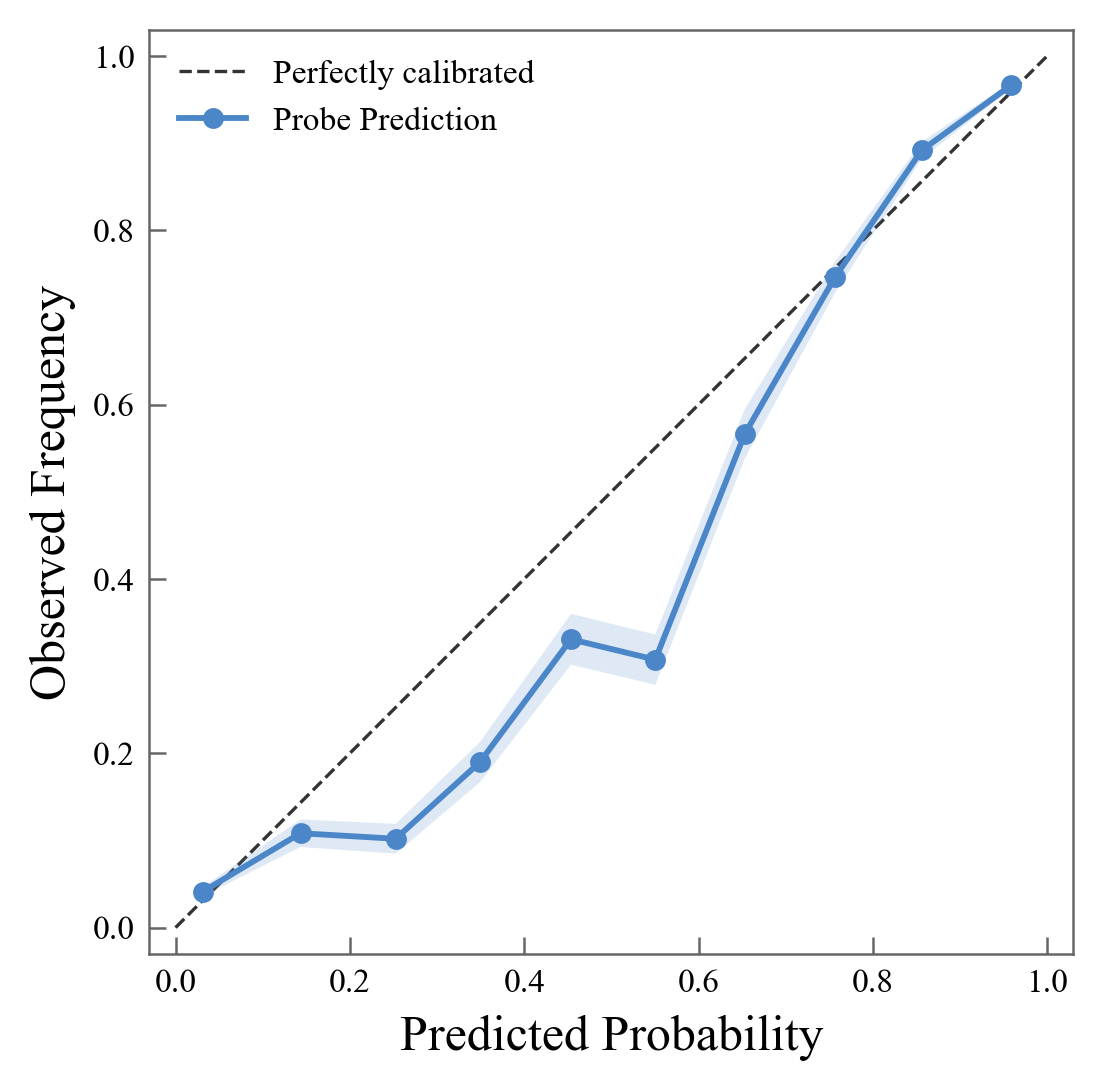

In [23]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_calibration(ax, [
    {**cal_llama, "color": "#4A86C8", "label": "Probe Prediction"},
    #{**cal_llama_temp, "color": "#ff9999", "label": "Temp. Scaled Probe Prediction"},
    #{**cal_llama_baseline,   "color": "#5A9E5A", "label": "Next Token Prediction"},
    #{**cal_llama_baseline_temp,   "color": "#E8945A", "label": "Temp. Scaled NTP"},
], title=None, annotate=False)
#fig.savefig("../figures/calibration_probe_only.pdf", bbox_inches="tight", dpi=300)

In [36]:
# ── Compute recovery curve values ──
def compute_recovery_curve(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = np.sum(bin_labels) / len(ground_truth_df)
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }

In [40]:
def plot_recovery_rate(
    ax,
    calibrations,          # list of dicts: {centers, means, ses, counts, color, label}
    title="",
    xlabel="Predicted Probability",
    ylabel="Recovery Rate",
    annotate=True,
    annotation_fontsize=7.5,
    legend_loc="upper left",
    xlim=(-0.03, 1.03),
    ylim=(-0.03, 1.03),
):
    # ── Each calibration curve ──
    for cal in calibrations:
        centers = cal["centers"]
        means   = cal["means"]
        ses     = cal["ses"]
        counts  = cal["counts"]
        color   = cal["color"]
        label   = cal["label"]

        # Shaded ±1 SE band
        ax.fill_between(
            centers, means - ses, means + ses,
            alpha=0.18, color=color, edgecolor="none", zorder=2,
        )
        # Line + markers
        ax.plot(
            centers, means, "o-",
            color=color, ms=4, lw=1.4, label=label, zorder=3,
        )
        # Bin-count annotations
        if annotate:
            for x, y, n in zip(centers, means, counts):
                txt = ax.annotate(
                    f"$n$={n}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=annotation_fontsize,
                    color="dimgray",
                )
                txt.set_path_effects([
                    mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
                ])

    # ── Axes formatting ──
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    # Lighten spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.4")
    ax.tick_params(width=0.6, color="0.4", labelsize=8)

    ax.legend(frameon=False, loc=legend_loc, fontsize=8)

In [47]:
recovery_cal_llama['means']

array([0.13049853, 0.03167155, 0.02639296, 0.03167155, 0.02815249,
       0.02697947, 0.03196481, 0.06392962, 0.09970674, 0.23167155])

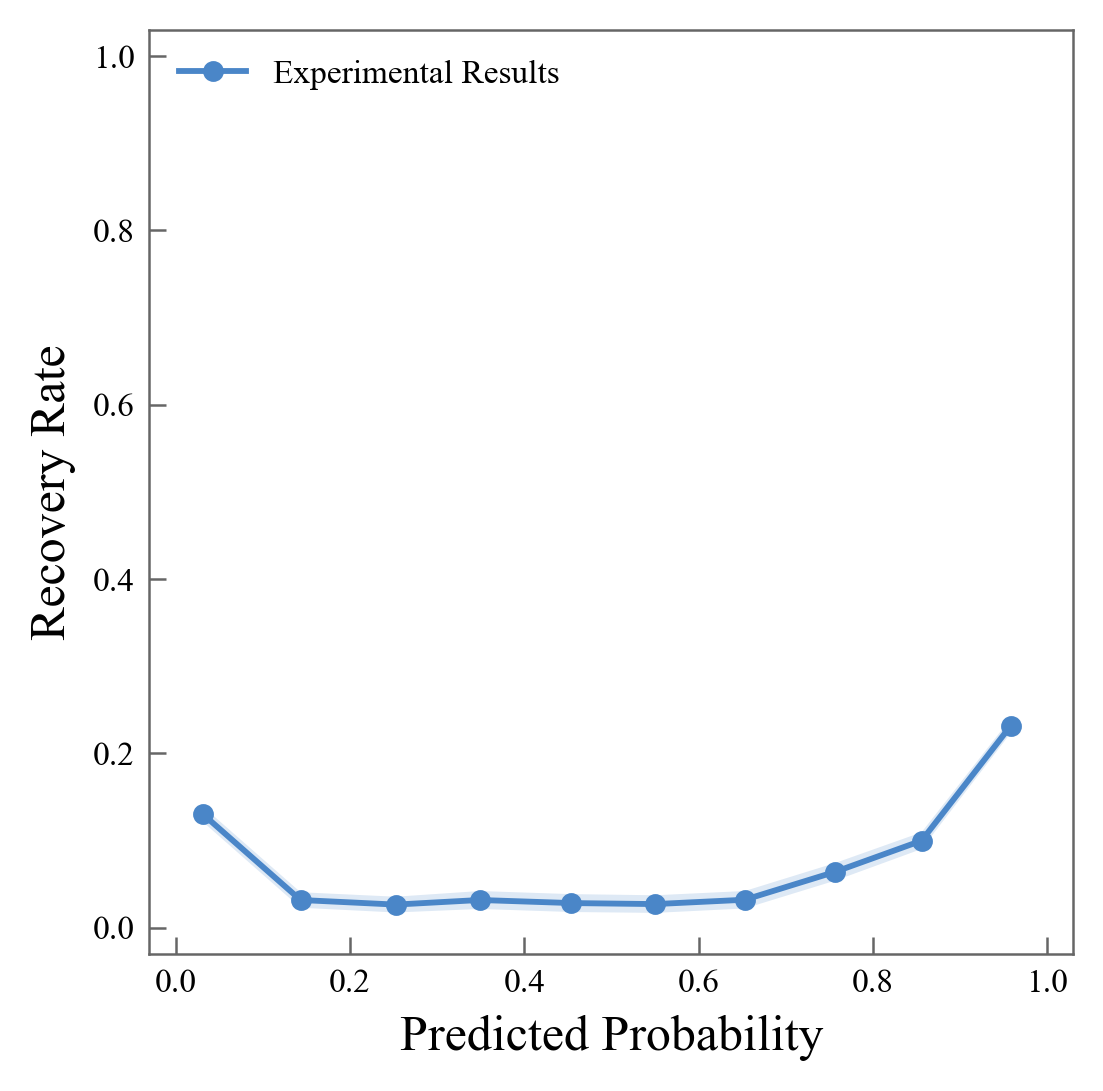

In [44]:
recovery_cal_llama = compute_recovery_curve(probs, matching_status, n_bins=10)

fig, ax = plt.subplots(figsize=(4, 4))
plot_recovery_rate(ax, [
    {**recovery_cal_llama, "color": "#4A86C8", "label": "Experimental Results"},
    #{**cal_llama_temp, "color": "#ff9999", "label": "Temp. Scaled Probe Prediction"},
    #{**cal_llama_baseline,   "color": "#5A9E5A", "label": "Next Token Prediction"},
    #{**cal_llama_baseline_temp,   "color": "#E8945A", "label": "Temp. Scaled NTP"},
], title=None, annotate=False)
fig.savefig("../figures/recovery_rates.pdf", bbox_inches="tight", dpi=100)

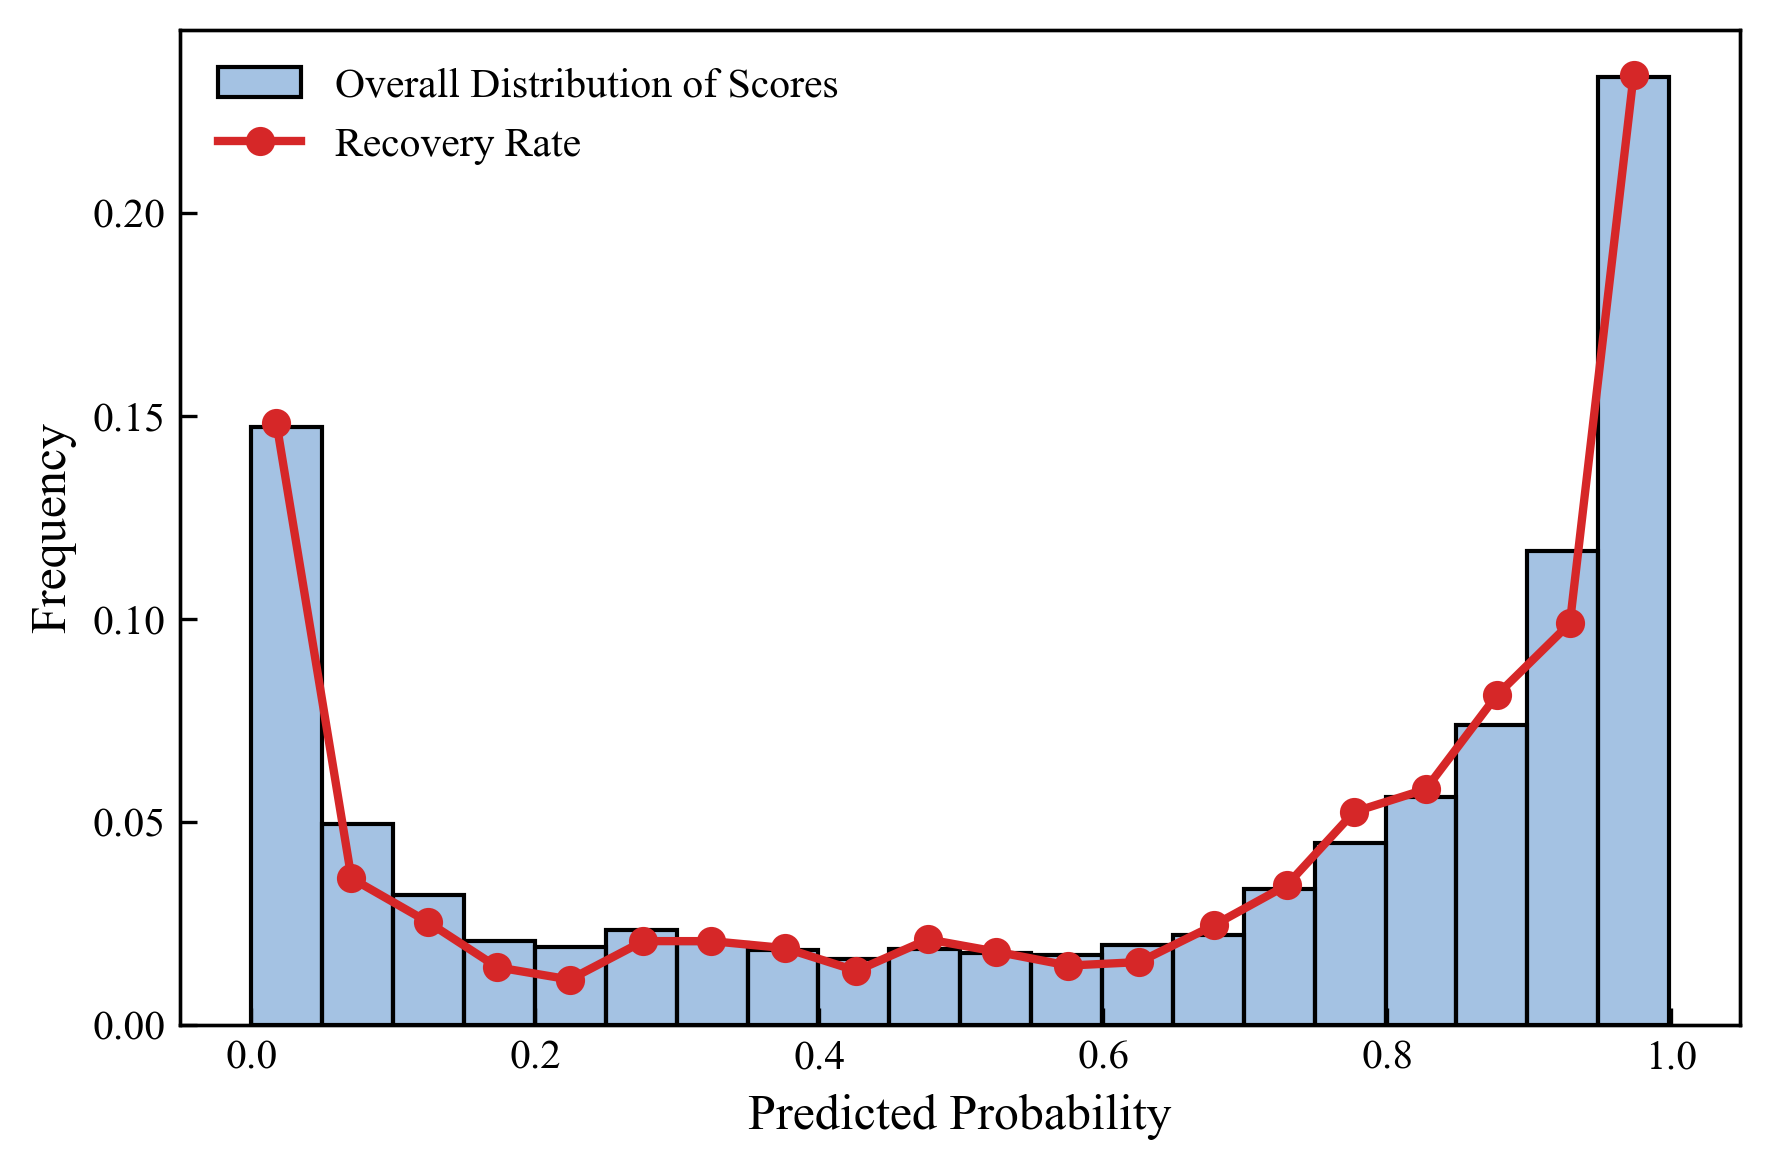

In [65]:
recovery_cal_llama = compute_recovery_curve(probs, matching_status, n_bins=20)

# Create a figure with overlaid probability distributions
fig, ax1 = plt.subplots(figsize=(6, 4))

# Left axis: Histogram of predicted probabilities
sns.histplot(probs, bins=20, alpha=0.5, color="#4A86C8", label="Overall Distribution of Scores", stat="probability", ax=ax1)
ax1.set_xlabel("Predicted Probability")
ax1.set_ylabel("Frequency")

# Right axis: Recovery rate by probability bin
ax2 = ax1.twinx()
centers = recovery_cal_llama['centers']
vals = recovery_cal_llama['means']
ax2.plot(centers, vals, "o-", color="#D62728", linewidth=2, markersize=6, label="Recovery Rate")
ax2.set_yticks([])

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("../figures/recovery_rate_with_histogram.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [55]:
probs

array([0.78893885, 0.79330261, 0.78514375, ..., 0.0097324 , 0.43942054,
       0.37694568], shape=(7407,))

ValueError: `bins` must increase monotonically, when an array

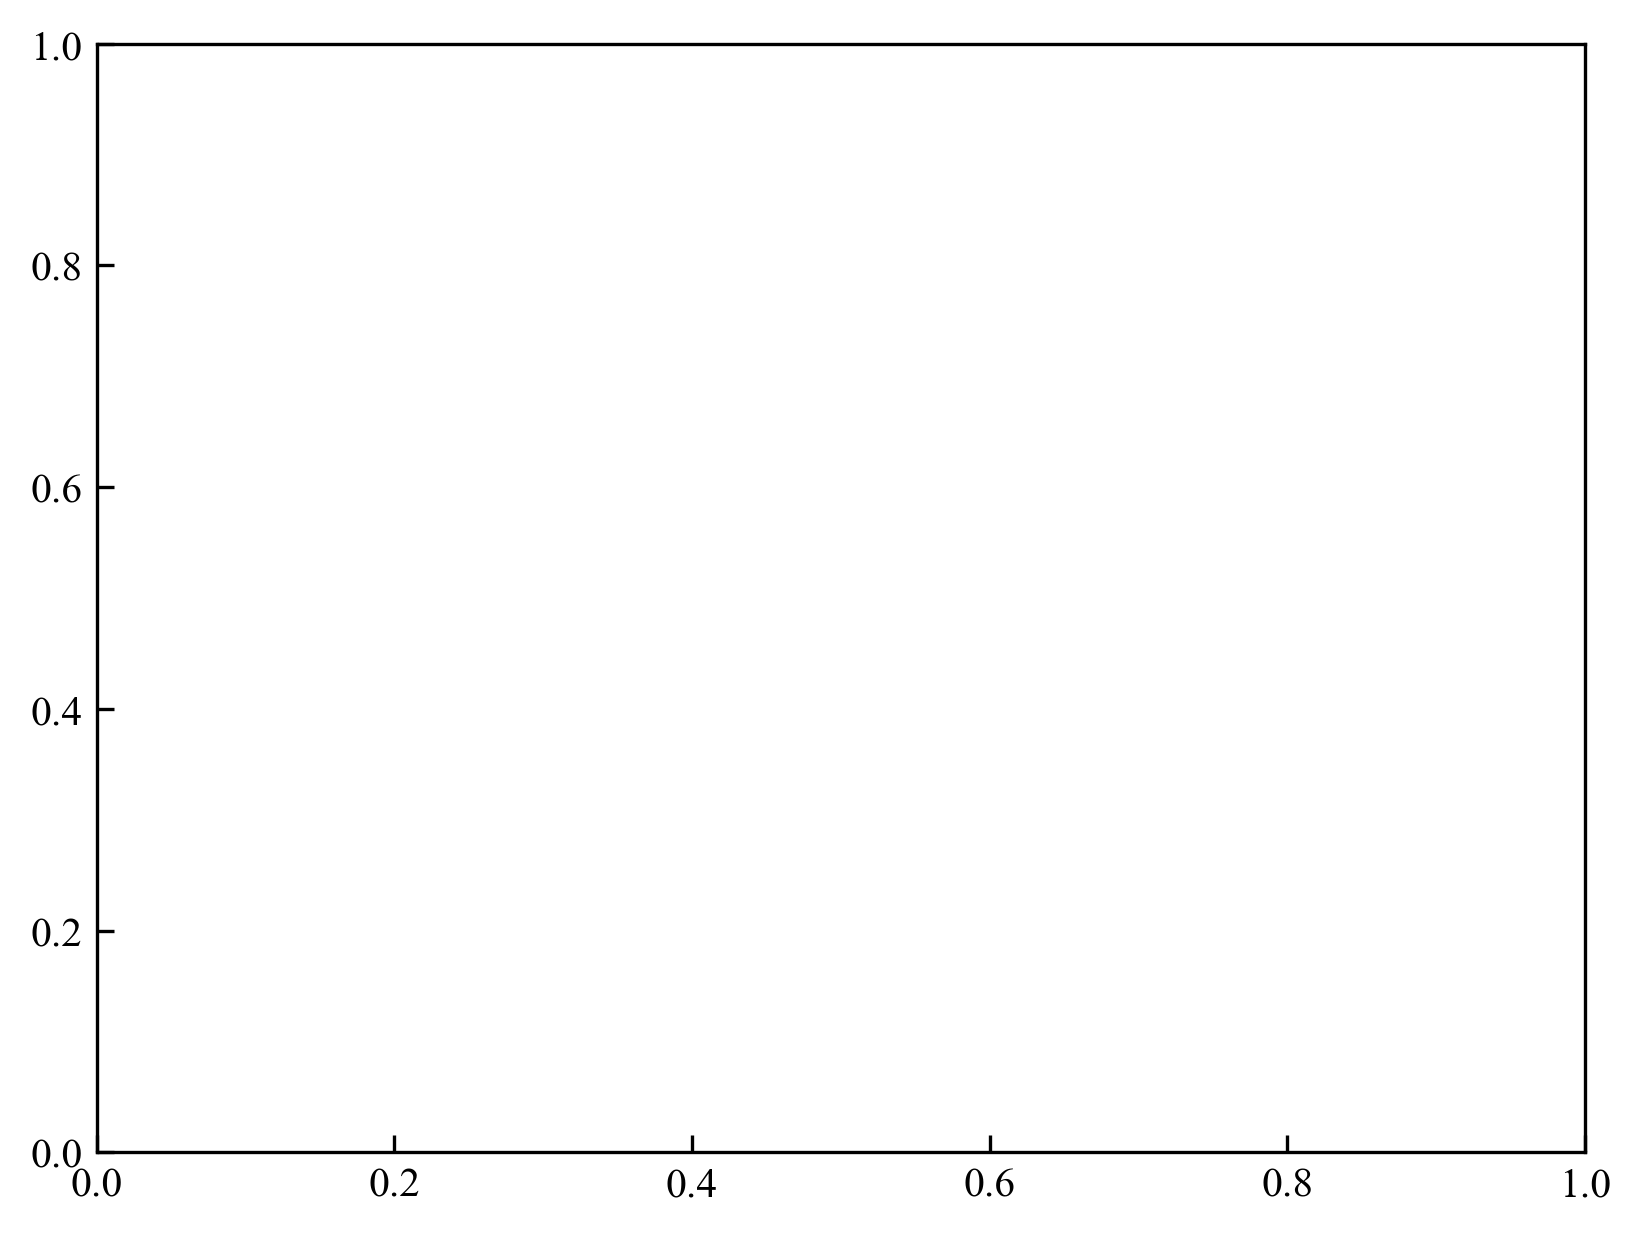

In [39]:
plt.hist(probs, matching_status)

In [28]:
recovery_cal_llama

{'centers': array([0.03096217, 0.14339649, 0.2525268 , 0.34906435, 0.45365783,
        0.55036506, 0.65304847, 0.756546  , 0.85583104, 0.95823417]),
 'means': array([0.30521262, 0.27835052, 0.2866242 , 0.37241379, 0.36923077,
        0.35797665, 0.35275081, 0.3713799 , 0.34800409, 0.30775224]),
 'ses': array([0.01206003, 0.02275324, 0.02551824, 0.02838903, 0.02992937,
        0.02990448, 0.02718257, 0.01994271, 0.01523938, 0.00911   ]),
 'counts': [1458, 388, 314, 290, 260, 257, 309, 587, 977, 2567]}

In [24]:
len(matching_status)

7407

In [25]:
len(probs)

7407

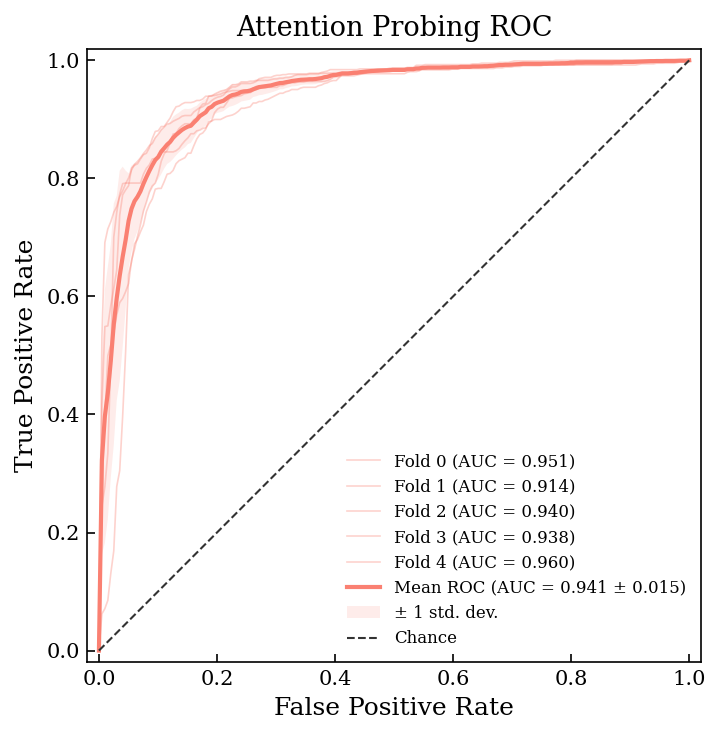

Attn head model avg. AUROC: 0.9406 ± 0.0153


In [37]:
# ── Plot ──
fig, ax = plt.subplots(figsize=(5, 5))

# Individual folds (light)
for i, (tpr_i, auc_i) in enumerate(zip(fold_tprs, fold_aucs)):
    ax.plot(mean_fpr_grid, tpr_i, lw=0.8, alpha=0.35, color="salmon",
            label=f"Fold {i} (AUC = {auc_i:.3f})")

# Mean ROC
ax.plot(mean_fpr_grid, mean_tpr, color="salmon", lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

# ±1 std band
ax.fill_between(
    mean_fpr_grid,
    np.clip(mean_tpr - std_tpr, 0, 1),
    np.clip(mean_tpr + std_tpr, 0, 1),
    color="salmon", alpha=0.15, edgecolor="none",
    label="± 1 std. dev.",
)

# Diagonal
ax.plot([0, 1], [0, 1], ls="--", color="#333333", lw=1, label="Chance")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Attention Probing ROC")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Attn head model avg. AUROC: {mean_auc:.4f} ± {std_auc:.4f}")

In [79]:
import pandas as pd

df = pd.read_csv("hf://datasets/Cleanlab/fire-financial-ner-extraction/fire_financial_ner_extraction.csv")

In [80]:
df

,text,ground_truth
0,Albertsons and Rite Aid called off the planned...,"{'Company': ['Albertsons', 'Rite Aid'], 'Date'..."
1,"EU clears merger of Essilor , Luxottica withou...","{'Company': ['Essilor', 'Luxottica'], 'Date': ..."
2,"On February 21 , Broadcom reduced their offer ...","{'Company': ['Broadcom', 'NXP Semconductors.',..."
3,Bank of America to Buy Merrill Lynch for $50 B...,"{'Company': ['Bank of America', 'Merrill Lynch..."
4,Broadcom cuts Qualcomm offer to $117 billion a...,"{'Company': ['Broadcom', 'NXP', 'Qualcomm', 'R..."
...,...,...
2112,The effectiveness of our internal control over...,"{'Company': ['PricewaterhouseCoopers LLP'], 'D..."
2113,The effectiveness of the Company s internal co...,"{'Company': ['PricewaterhouseCoopers LLP'], 'D..."
2114,The Company realized tax deductions of $ 7.3 m...,"{'Company': None, 'Date': ['2009'], 'Location'..."
2115,The effectiveness of our internal control over...,"{'Company': ['Ernst Young'], 'Date': ['Decembe..."


In [85]:
df.iloc[2].text

'On February 21 , Broadcom reduced their offer to $117 billion in light of Qualcomms increased bid for NXP Semconductors. The deal was effectively blocked after US President Donald Trump blocked any deal based upon national security grounds .'

In [86]:
df.iloc[2].ground_truth

"{'Company': ['Broadcom', 'NXP Semconductors.', 'Qualcomms'], 'Date': ['February 21'], 'Location': ['US'], 'Money': ['$117 billion'], 'Person': ['Donald Trump'], 'Product': None, 'Quantity': None}"